# Download ETTh1

In [1]:
!wget -q "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"

import pandas as pd
import numpy as np
import torch

df = pd.read_csv('ETTh1.csv')
df = df.drop(columns=['date'])
print(df.shape)
print(df.head())
print(df.describe())

(17420, 7)
    HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
0  5.827  2.009  1.599  0.462  4.203  1.340  30.531000
1  5.693  2.076  1.492  0.426  4.142  1.371  27.787001
2  5.157  1.741  1.279  0.355  3.777  1.218  27.787001
3  5.090  1.942  1.279  0.391  3.807  1.279  25.044001
4  5.358  1.942  1.492  0.462  3.868  1.279  21.948000
               HUFL          HULL          MUFL          MULL          LUFL  \
count  17420.000000  17420.000000  17420.000000  17420.000000  17420.000000   
mean       7.375141      2.242242      4.300239      0.881568      3.066062   
std        7.067744      2.042342      6.826978      1.809293      1.164506   
min      -22.705999     -4.756000    -25.087999     -5.934000     -1.188000   
25%        5.827000      0.737000      3.296000     -0.284000      2.315000   
50%        8.774000      2.210000      5.970000      0.959000      2.833000   
75%       11.788000      3.684000      8.635000      2.203000      3.625000   
max       23.643999     10.

# Build sequences


In [2]:
def make_sequences(data, input_len=336, pred_len=96):
    X, y = [], []
    for i in range(len(data) - input_len - pred_len):
        X.append(data[i : i+input_len])
        y.append(data[i+input_len : i+input_len+pred_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Use only the target column (OT = oil temperature) first
# Clean, single variable, standard benchmark
values = df['OT'].values.reshape(-1, 1)

# Train/val/test split — standard for ETTh1
n = len(values)
train_end = int(n * 0.6)
val_end   = int(n * 0.8)

train_data = values[:train_end]
val_data   = values[train_end:val_end]
test_data  = values[val_end:]

# Normalize using train statistics only
mean = train_data.mean()
std  = train_data.std()
train_data = (train_data - mean) / std
val_data   = (val_data - mean) / std
test_data  = (test_data - mean) / std

# Build sequences
X_train, y_train = make_sequences(train_data)
X_val,   y_val   = make_sequences(val_data)
X_test,  y_test  = make_sequences(test_data)

print(f"Train: {X_train.shape} -> {y_train.shape}")
print(f"Val:   {X_val.shape}   -> {y_val.shape}")
print(f"Test:  {X_test.shape}  -> {y_test.shape}")

Train: (10020, 336, 1) -> (10020, 96, 1)
Val:   (3052, 336, 1)   -> (3052, 96, 1)
Test:  (3052, 336, 1)  -> (3052, 96, 1)


# DataLoaders

In [3]:
from torch.utils.data import DataLoader, TensorDataset

def make_loader(X, y, batch_size=32, shuffle=False):
    X_t = torch.tensor(X).permute(0, 2, 1)  # (batch, 1, T)
    y_t = torch.tensor(y).squeeze(-1)        # (batch, pred_len)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val)
test_loader  = make_loader(X_test,  y_test)

# CNN + Temporal Pooling

In [4]:
import torch.nn as nn

class CNN_TemporalPooling_Forecast(nn.Module):
    def __init__(self, pred_len=96):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),   # 336 -> 168

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),   # 168 -> 84

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.forecaster = nn.Linear(128, pred_len)

    def forward(self, x):
        x = self.network(x)
        x = self.gap(x).squeeze(-1)
        return self.forecaster(x)

# CNN + LSTM

In [5]:
class CNN_LSTM_Forecast(nn.Module):
    def __init__(self, pred_len=96):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(input_size=128, hidden_size=128,
                            num_layers=2, batch_first=True)
        self.forecaster = nn.Linear(128, pred_len)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 2, 1)       # (batch, T, 128)
        _, (h_n, _) = self.lstm(x)
        return self.forecaster(h_n[-1])

# Training

In [11]:
import time
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

def train_forecast(model, train_loader, test_loader, epochs=50, lr=1e-3, patience=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    train_losses, test_mses = [], []
    best_mse = float('inf')
    patience_counter = 0
    start = time.time()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        model.eval()
        preds, actuals = [], []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                pred = model(X_batch.to(device)).cpu().numpy()
                preds.extend(pred)
                actuals.extend(y_batch.numpy())

        preds   = np.array(preds)
        actuals = np.array(actuals)
        mse = mean_squared_error(actuals.flatten(), preds.flatten())
        mae = mean_absolute_error(actuals.flatten(), preds.flatten())

        train_losses.append(epoch_loss / len(train_loader))
        test_mses.append(mse)

        # Early stopping
        if mse < best_mse:
            best_mse = mse
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1} | Loss: {train_losses[-1]:.4f} | MSE: {mse:.4f} | MAE: {mae:.4f}")

    training_time = time.time() - start
    return train_losses, test_mses, training_time, best_mse, mae

In [12]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(123)

# Results and Plots

In [13]:
import pickle
import torch.optim as optim

set_seed(123)
print("Training CNN + Temporal Pooling...")
pool_model = CNN_TemporalPooling_Forecast()
pool_losses, pool_mses, pool_time, pool_final_mse, pool_final_mae = train_forecast(
    pool_model, train_loader, test_loader)

set_seed(123)
print("\nTraining CNN + LSTM...")
lstm_model = CNN_LSTM_Forecast()
lstm_losses, lstm_mses, lstm_time, lstm_final_mse, lstm_final_mae = train_forecast(
    lstm_model, train_loader, test_loader)

# Save immediately
with open('etth1_curves.pkl', 'wb') as f:
    pickle.dump({
        'pool_losses': pool_losses, 'lstm_losses': lstm_losses,
        'pool_mses': pool_mses,     'lstm_mses': lstm_mses,
    }, f)

print("\n--- Final Results on ETTh1 ---")
print(f"CNN+Pooling | MSE: {pool_final_mse:.4f} | MAE: {pool_final_mae:.4f} | Time: {pool_time:.1f}s")
print(f"CNN+LSTM    | MSE: {lstm_final_mse:.4f} | MAE: {lstm_final_mae:.4f} | Time: {lstm_time:.1f}s")

Training CNN + Temporal Pooling...
Epoch 5 | Loss: 0.1710 | MSE: 0.1073 | MAE: 0.2557
Epoch 10 | Loss: 0.1455 | MSE: 0.1148 | MAE: 0.2700
Early stopping at epoch 11

Training CNN + LSTM...
Epoch 5 | Loss: 0.1499 | MSE: 0.1533 | MAE: 0.3077
Early stopping at epoch 7

--- Final Results on ETTh1 ---
CNN+Pooling | MSE: 0.0913 | MAE: 0.2507 | Time: 91.9s
CNN+LSTM    | MSE: 0.1155 | MAE: 0.2706 | Time: 921.9s


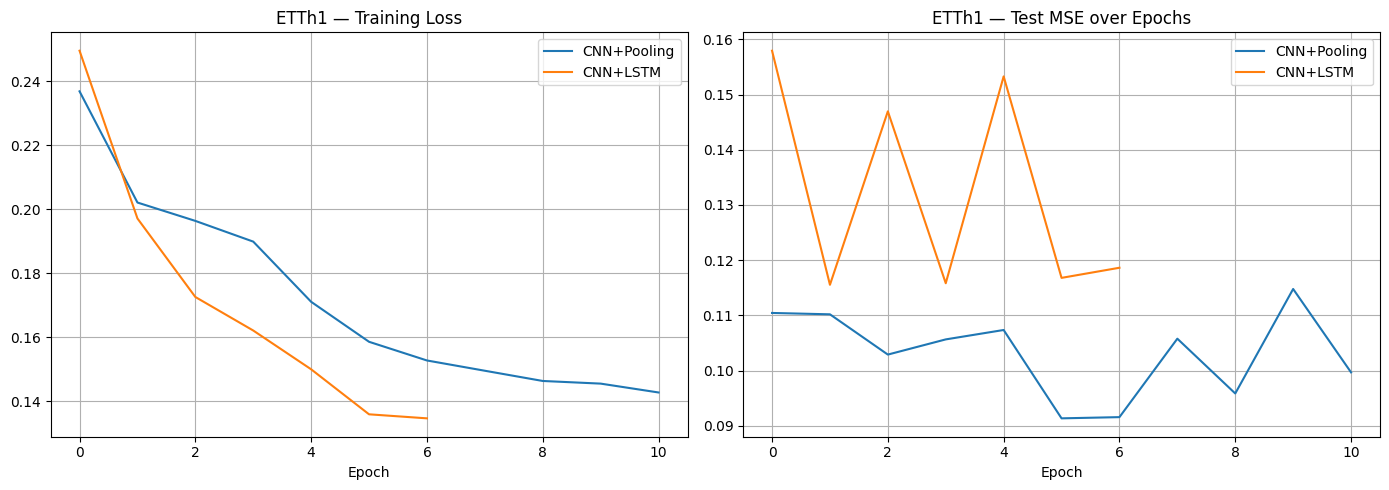

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(pool_losses, label='CNN+Pooling')
axes[0].plot(lstm_losses, label='CNN+LSTM')
axes[0].set_title('ETTh1 — Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(pool_mses, label='CNN+Pooling')
axes[1].plot(lstm_mses, label='CNN+LSTM')
axes[1].set_title('ETTh1 — Test MSE over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()